# Trackeo de los compuestos quimicos en la simulacion



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tripodpy
import dustpy.constants as c

# Create simulation object
sim = tripodpy.Simulation()

# Basic setup
sim.ini.grid.Nr = 50
sim.ini.grid.rmin = 1.0 * c.au
sim.ini.grid.rmax = 1000.0 * c.au

# Initialize the simulation
sim.initialize()

In [2]:
sim.components


Group (components)
------------------
    Default      : Group (Default gas componentDefault (dust_tracer=False, gas_active=True, gas_tracer=False))
  -----

In [ ]:
sim.t.snapshots = np.linspace(0,1e6*c.year,20)

tr_gas = np.ones_like(sim.grid.r)*1e-5
tr_gas[sim.grid.r<10*c.au] = 1.0
tr_dust = tr_gas[:,None]*np.ones_like(sim.dust.Sigma)
sim.addcomponent("tr_gas",tr_gas,0.32,gas_tracer=True)
sim.addcomponent("tr_dust",tr_dust,0.32,dust_value=tr_dust,dust_tracer=True)



In [8]:
sim.writer.datadir = "5.1_data"
sim.writer.overwrite = True

In [9]:
sim.run()


tripodpy v1.0.0

Writing file 5.1_data\data0000.hdf5
Writing dump file 5.1_data\frame.dmp
Writing file 5.1_data\data0001.hdf5
Writing dump file 5.1_data\frame.dmp
Writing file 5.1_data\data0002.hdf5
Writing dump file 5.1_data\frame.dmp
Writing file 5.1_data\data0003.hdf5
Writing dump file 5.1_data\frame.dmp
Writing file 5.1_data\data0004.hdf5
Writing dump file 5.1_data\frame.dmp
Writing file 5.1_data\data0005.hdf5
Writing dump file 5.1_data\frame.dmp
Writing file 5.1_data\data0006.hdf5
Writing dump file 5.1_data\frame.dmp
Writing file 5.1_data\data0007.hdf5
Writing dump file 5.1_data\frame.dmp
Writing file 5.1_data\data0008.hdf5
Writing dump file 5.1_data\frame.dmp
Writing file 5.1_data\data0009.hdf5
Writing dump file 5.1_data\frame.dmp
Writing file 5.1_data\data0010.hdf5
Writing dump file 5.1_data\frame.dmp
Writing file 5.1_data\data0011.hdf5
Writing dump file 5.1_data\frame.dmp
Writing file 5.1_data\data0012.hdf5
Writing dump file 5.1_data\frame.dmp
Writing file 5.1_data\data0013.hd

In [30]:
from dustpy import hdf5writer
wrtr = hdf5writer()
wrtr.datadir = "5.1_data"
data = wrtr.read.all()

print(vars(data.components.tr_gas.gas).keys())

data.components.tr_gas.gas.Fi

dict_keys(['Fi', 'S', 'pars'])


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(20, 51))

AttributeError: 'SimpleNamespace' object has no attribute 'value'

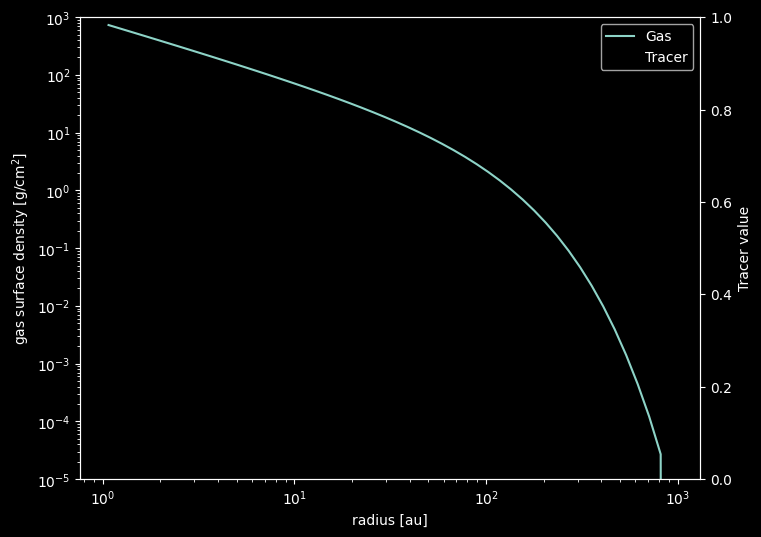

In [44]:
plt.figure(figsize=(8,6))
plt.plot(sim.grid.r/c.au, sim.components.Default.gas.Sigma, label="Gas")
plt.plot([],[],'k--',label='Tracer')
plt.yscale("log")
plt.xscale("log")
plt.ylim(1e-5, 1e3)
plt.legend()
plt.xlabel('radius [au]')
plt.ylabel(r'gas surface density [g/cm$^2$]')
ax2 = plt.twinx()
ax2.set_ylabel('Tracer value')

for t in range(len(data.t))[::4]:
    ax2.plot(sim.grid.r/c.au, data.components.tr_gas.gas.value[t,:,0],"k--")

AttributeError: 'SimpleNamespace' object has no attribute 'value'

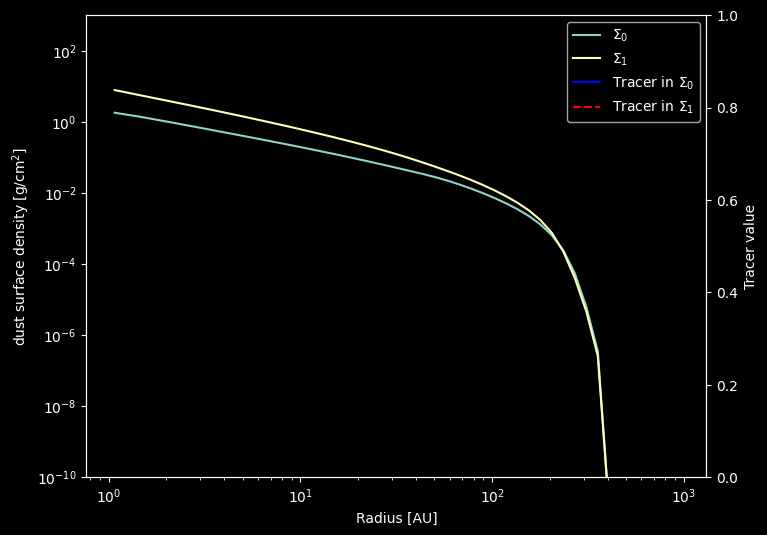

In [45]:
plt.figure(figsize=(8,6))
plt.plot(sim.grid.r/c.au, sim.dust.Sigma[:,0], label=r"$\Sigma_0$")
plt.plot(sim.grid.r/c.au, sim.dust.Sigma[:,1], label=r"$\Sigma_1$")
plt.plot([],[],'b',label=r'Tracer in $\Sigma_0$')
plt.plot([],[],'r--',label=r'Tracer in $\Sigma_1$')
plt.legend()

plt.yscale("log")
plt.xscale("log")
plt.xlabel('Radius [AU]')
plt.ylabel(r'dust surface density [g/cm$^2$]')
plt.ylim(1e-10, 1e3)
ax2 = plt.twinx()
ax2.set_ylabel('Tracer value')

for t in range(len(data.t))[::4]:
    ax2.plot(sim.grid.r/c.au, data.components.tr_dust.dust.value[t,:,0],"b" )
    ax2.plot(sim.grid.r/c.au, data.components.tr_dust.dust.value[t,:,1],"r--")

plt.plot(sim.grid.r/c.au,tr_dust,'k--',label='Initial condition')
plt.show()


In [46]:
sim = tripodpy.Simulation()
sim.ini.grid.rmin = 1 * c.au
sim.ini.grid.rmax = 1000 * c.au
sim.ini.grid.Nr = 500
sim.ini.gas.SigmaRc = 100*c.au
sim.initialize()
sim.t.snapshots = np.linspace(0,1e6*c.year,20)

dust_value1 = sim.dust.Sigma.copy()
dust_value1[sim.grid.r<10*c.au] = 1e-11
dust_value2 = sim.dust.Sigma.copy()
dust_value2[sim.grid.r>10*c.au] = 1e-11
sim.addcomponent("dust1",sim.gas.SigmaFloor,1,dust_value=dust_value1 ,dust_active=True, gas_active=False, gas_tracer=False,rhos=sim.dust.rhos[0,0])
sim.addcomponent("dust2",sim.gas.SigmaFloor,1,dust_value=dust_value2 ,dust_active=True, gas_active=False, gas_tracer=False,rhos=sim.dust.rhos[0,0])

sim.writer.datadir = "5.2_data"

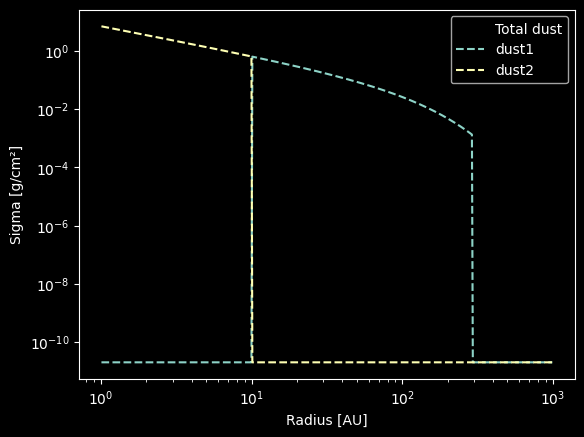

In [47]:
plt.figure()
plt.plot(sim.grid.r/c.au,sim.dust.Sigma.sum(-1),"k",label="Total dust")
plt.plot(sim.grid.r/c.au,sim.components.dust1.dust.Sigma.sum(-1),"--",label="dust1")
plt.plot(sim.grid.r/c.au,sim.components.dust2.dust.Sigma.sum(-1),"--",label="dust2")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Radius [AU]")
plt.ylabel("Sigma [g/cm²]")
plt.legend()
plt.show()

In [48]:
sim.run()



tripodpy v1.0.0

Creating data directory 5.2_data.
Writing file 5.2_data\data0000.hdf5
Writing dump file 5.2_data\frame.dmp
Writing file 5.2_data\data0001.hdf5
Writing dump file 5.2_data\frame.dmp
Writing file 5.2_data\data0002.hdf5
Writing dump file 5.2_data\frame.dmp
Writing file 5.2_data\data0003.hdf5
Writing dump file 5.2_data\frame.dmp
Writing file 5.2_data\data0004.hdf5
Writing dump file 5.2_data\frame.dmp
Writing file 5.2_data\data0005.hdf5
Writing dump file 5.2_data\frame.dmp
Writing file 5.2_data\data0006.hdf5
Writing dump file 5.2_data\frame.dmp
Writing file 5.2_data\data0007.hdf5
Writing dump file 5.2_data\frame.dmp
Writing file 5.2_data\data0008.hdf5
Writing dump file 5.2_data\frame.dmp
Writing file 5.2_data\data0009.hdf5
Writing dump file 5.2_data\frame.dmp
Writing file 5.2_data\data0010.hdf5
Writing dump file 5.2_data\frame.dmp
Writing file 5.2_data\data0011.hdf5
Writing dump file 5.2_data\frame.dmp
Writing file 5.2_data\data0012.hdf5
Writing dump file 5.2_data\frame.dmp

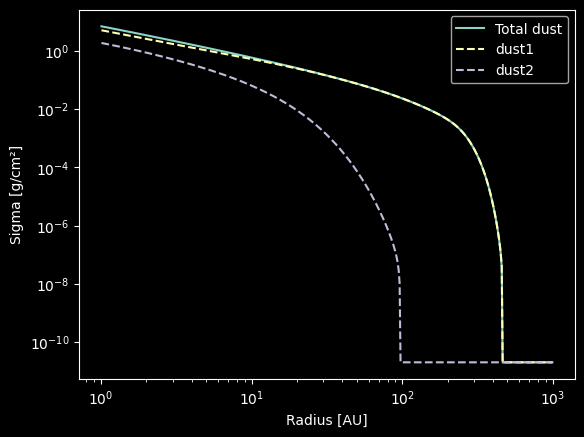

In [49]:
plt.figure()
plt.plot(sim.grid.r/c.au,sim.dust.Sigma.sum(-1),label="Total dust")


plt.plot(sim.grid.r/c.au,sim.components.dust1.dust.Sigma.sum(-1),"--" ,label="dust1")
plt.plot(sim.grid.r/c.au,sim.components.dust2.dust.Sigma.sum(-1),"--" ,label="dust2")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Radius [AU]")
plt.ylabel("Sigma [g/cm²]")
plt.legend()
plt.show()

In [50]:
sim_compo = tripodpy.Simulation()
sim_compo.ini.grid.rmin = 1 * c.au
sim_compo.ini.grid.rmax = 1000 * c.au
sim_compo.ini.grid.Nr = 500
sim_compo.ini.gas.SigmaRc = 100*c.au
sim_compo.initialize()
sim_compo.t.snapshots = np.linspace(0,1e6*c.year,20)

sim_compo.writer.datadir = "5.3_data"

dust_value=np.minimum(sim_compo.gas.Sigma*5e-3,sim_compo.dust.Sigma.sum(-1))
dust_value =  dust_value[:,None] * 0.5
# Adds bcakground dust
sim_compo.addcomponent("default_dust",sim_compo.gas.SigmaFloor,1,dust_value=sim_compo.dust.Sigma ,dust_active=True, gas_active=False, gas_tracer=False,rhos=sim_compo.dust.rhos[0,0])
#add the CO component
sim_compo.addcomponent("CO",sim_compo.gas.SigmaFloor,1,dust_value=dust_value ,dust_active=True, gas_active=True,rhos=1.)

In [51]:
# Set CO parameters for condensation/evaporation
sim_compo.components.CO.gas.pars.mu = 28 * c.m_p
sim_compo.components.CO.gas.pars.nu = 7.0e11
sim_compo.components.CO.gas.pars.Tsub = 1180
sim_compo.components.CO.dust.pars.rhos = 1.0

#update dust internal density -> changed when adding new component
sim_compo.dust.rhos.update()

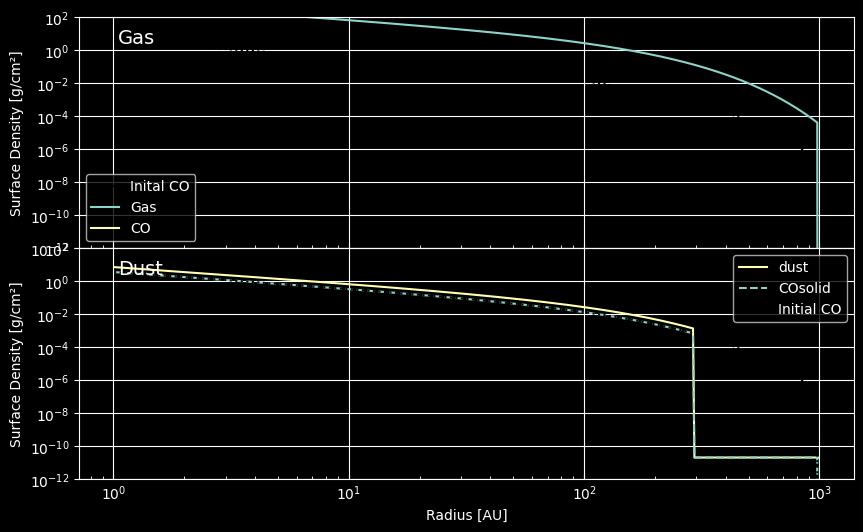

In [52]:
fg,axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axs[0].plot(sim_compo.grid.r/c.au,sim_compo.gas.Sigma*5e-3,"k:", label="Inital CO")

axs[0].plot(sim_compo.grid.r/c.au,sim_compo.components.Default.gas.Sigma,label="Gas")
p = axs[0].plot(sim_compo.grid.r/c.au,sim_compo.components.CO.gas.Sigma,label="CO")

axs[1].plot(sim_compo.grid.r/c.au, sim_compo.components.default_dust.dust.Sigma.sum(-1),color =p[0].get_color(),label="dust")
axs[1].plot(sim_compo.grid.r/c.au, sim_compo.components.CO.dust.Sigma.sum(-1),"--",label="COsolid")


axs[1].plot(sim_compo.grid.r/c.au,sim_compo.gas.Sigma*5e-3,"k:",label='Initial CO')
axs[0].legend()
axs[1].legend()
plt.subplots_adjust(hspace=0)
axs[0].tick_params(axis='x', direction='in')
axs[1].tick_params(axis='x', direction='in')
axs[0].tick_params(axis='x', which='minor', direction='in')
axs[1].tick_params(axis='x', which='minor', direction='in')
axs[0].text(0.05, 0.95, 'Gas', transform=axs[0].transAxes, fontsize=14, verticalalignment='top')
axs[1].text(0.05, 0.95, 'Dust', transform=axs[1].transAxes, fontsize=14, verticalalignment='top')
for ax in axs:
    ax.set_xlabel('Radius [AU]')
    ax.set_ylabel('Surface Density [g/cm²]')
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_ylim(1e-12, 1e2)
    ax.grid()
plt.show()

In [53]:
sim_compo.run()



tripodpy v1.0.0

Creating data directory 5.3_data.
Writing file 5.3_data\data0000.hdf5
Writing dump file 5.3_data\frame.dmp
Writing file 5.3_data\data0001.hdf5
Writing dump file 5.3_data\frame.dmp
Writing file 5.3_data\data0002.hdf5
Writing dump file 5.3_data\frame.dmp
Writing file 5.3_data\data0003.hdf5
Writing dump file 5.3_data\frame.dmp
Writing file 5.3_data\data0004.hdf5
Writing dump file 5.3_data\frame.dmp
Writing file 5.3_data\data0005.hdf5
Writing dump file 5.3_data\frame.dmp
Writing file 5.3_data\data0006.hdf5
Writing dump file 5.3_data\frame.dmp
Writing file 5.3_data\data0007.hdf5
Writing dump file 5.3_data\frame.dmp
Writing file 5.3_data\data0008.hdf5
Writing dump file 5.3_data\frame.dmp
Writing file 5.3_data\data0009.hdf5
Writing dump file 5.3_data\frame.dmp
Writing file 5.3_data\data0010.hdf5
Writing dump file 5.3_data\frame.dmp
Writing file 5.3_data\data0011.hdf5
Writing dump file 5.3_data\frame.dmp
Writing file 5.3_data\data0012.hdf5
Writing dump file 5.3_data\frame.dmp

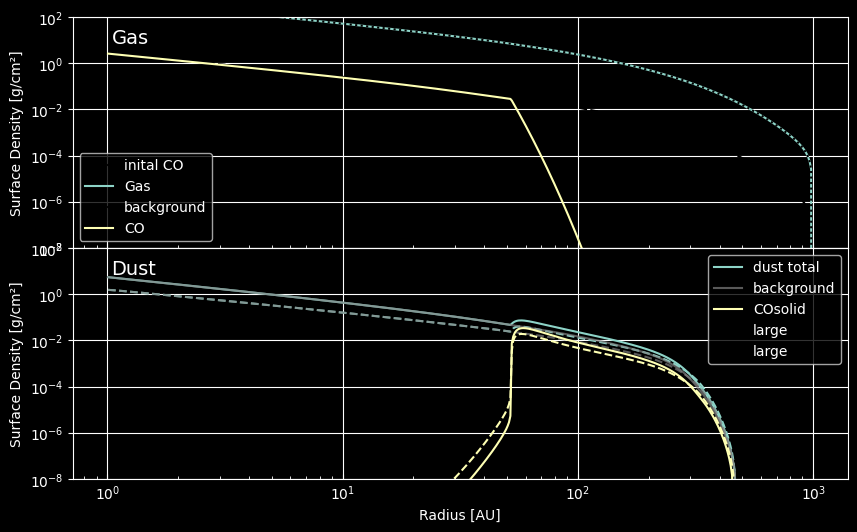

In [54]:
fg,axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axs[0].plot(sim_compo.grid.r/c.au,sim_compo.gas.Sigma*5e-3,"k--", label="inital CO")

p1 = axs[0].plot(sim_compo.grid.r/c.au,sim_compo.gas.Sigma,label="Gas")
axs[0].plot(sim_compo.grid.r/c.au,sim_compo.components.Default.gas.Sigma,"k:",label="background")
p = axs[0].plot(sim_compo.grid.r/c.au,sim_compo.components.CO.gas.Sigma,label="CO")

axs[1].plot(sim_compo.grid.r/c.au, sim_compo.dust.Sigma[:,0],"--",color =p1[0].get_color())
axs[1].plot(sim_compo.grid.r/c.au, sim_compo.dust.Sigma[:,1],color =p1[0].get_color(),label="dust total")

axs[1].plot(sim_compo.grid.r/c.au, sim_compo.components.default_dust.dust.Sigma[:,0],"--",color ="gray", alpha =0.7)
axs[1].plot(sim_compo.grid.r/c.au, sim_compo.components.default_dust.dust.Sigma[:,1],color ="gray", alpha =0.7,label="background")

axs[1].plot(sim_compo.grid.r/c.au, sim_compo.components.CO.dust.Sigma[:,0],"--",color =p[0].get_color())
axs[1].plot(sim_compo.grid.r/c.au, sim_compo.components.CO.dust.Sigma[:,1],color =p[0].get_color(),label="COsolid")

axs[1].plot([],[], label='large', color="k")
axs[1].plot([],[], "k--",label='large')
axs[0].legend()
axs[1].legend()
plt.subplots_adjust(hspace=0)
axs[0].tick_params(axis='x', direction='in')
axs[1].tick_params(axis='x', direction='in')
axs[0].tick_params(axis='x', which='minor', direction='in')
axs[1].tick_params(axis='x', which='minor', direction='in')
axs[0].text(0.05, 0.95, 'Gas', transform=axs[0].transAxes, fontsize=14, verticalalignment='top')
axs[1].text(0.05, 0.95, 'Dust', transform=axs[1].transAxes, fontsize=14, verticalalignment='top')
for ax in axs:
    ax.set_xlabel('Radius [AU]')
    ax.set_ylabel('Surface Density [g/cm²]')
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_ylim(1e-8, 1e2)
    ax.grid()
plt.show()

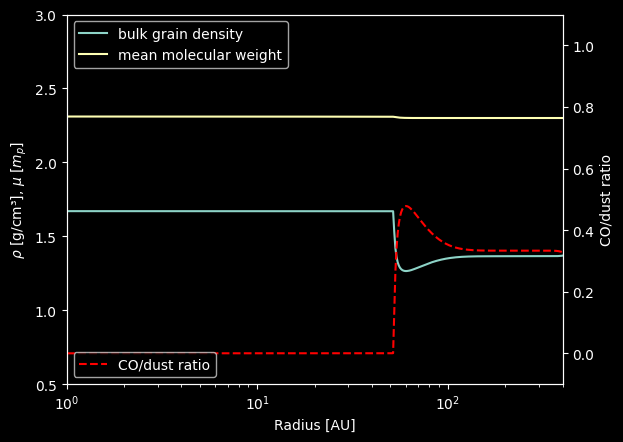

In [55]:
plt.figure()
plt.plot(sim_compo.grid.r/c.au,sim_compo.dust.rhos[:,1],label="bulk grain density")
plt.plot(sim_compo.grid.r/c.au,sim_compo.gas.mu/c.m_p,label="mean molecular weight")
plt.xscale("log")
plt.ylabel(r"$\rho$ [g/cm³], $\mu$ [$m_p$]")
plt.xlabel("Radius [AU]")
plt.ylim(0.5,3)
plt.legend(loc= "upper left")
ax = plt.gca()
ax2 = ax.twinx()
ax2.plot(sim_compo.grid.r/c.au,sim_compo.components.CO.dust.Sigma.sum(-1)/sim_compo.dust.Sigma.sum(-1),"--",color="r",label="CO/dust ratio")
plt.ylabel("CO/dust ratio")
plt.ylim(-0.1,1.1)
plt.xlim(1,400)
plt.legend(loc="lower left")
plt.show()